# Bimodularity community detection (FlyWire)

Notebook version of `notebooks/bimodularity_flywire.py`.

Running all cells produces the same saved artifacts as the script:
- `output/bimodularity/adjacency_reordered_<run_tag>.png`
- `output/bimodularity/block_matrices_<run_tag>.png`
- `output/bimodularity/bicommunity_submatrices_<run_tag>.png`
- `output/bimodularity/slice_node_assignments_<run_tag>.csv`
- `output/bimodularity/bimodularity_cluster_contributions_<run_tag>.csv`

The default slice strategy is **cycle**: find a small set of Louvain modules forming a directed cycle (high asymmetric flow), then sample boundary nodes so multiple edge bicommunities appear under bimodularity.

In [26]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
import importlib.util

sns.set_context("talk")
sns.set_style("white")

cwd = Path.cwd().resolve()
if (cwd / "data").exists() and (cwd / "notebooks").exists():
    repo_root = cwd
elif cwd.name == "notebooks" and (cwd.parent / "data").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

module_path = repo_root / "notebooks" / "bimodularity_flywire.py"
module_name = "bimodularity_flywire_impl"
spec = importlib.util.spec_from_file_location(module_name, module_path)
bi = importlib.util.module_from_spec(spec)
# dataclasses (and other libs) expect the module to exist in sys.modules during exec
sys.modules[module_name] = bi
assert spec.loader is not None
spec.loader.exec_module(bi)
print("Loaded:", module_path)
print("Has pick_slice_via_directed_cycle_search:", hasattr(bi, "pick_slice_via_directed_cycle_search"))

print("repo_root:", repo_root)

Loaded: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\notebooks\bimodularity_flywire.py
Has pick_slice_via_directed_cycle_search: True
repo_root: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis


## Parameters

Set `seed` to explore other slices. The `cycle` strategy is usually what produces multiple distinct edge bicommunities.

In [27]:
graph_pkl = repo_root / "data/preprocessed/subgraph.pkl"

slice_strategy = "cycle"  # "cycle" or "single"
nodes_min, nodes_max = 120, 180
seed = 2

gamma = 1.0
svd_rank = 6
min_edge_weight = 1.0
max_edges = 12000

# If 0, use slice_info.meta['picked_k'] when present, else scan [clusters_min, clusters_max].
clusters = 0
clusters_min, clusters_max = 4, 12

print("graph_pkl:", graph_pkl)
print("slice_strategy:", slice_strategy, "seed:", seed, "n in [", nodes_min, ",", nodes_max, "]")

graph_pkl: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\data\preprocessed\subgraph.pkl
slice_strategy: cycle seed: 2 n in [ 120 , 180 ]


## Load FlyWire directed subgraph

In [28]:
G_full = bi.load_flywire_subgraph_pickle(graph_pkl)
print(type(G_full), "nodes=", G_full.number_of_nodes(), "edges=", G_full.number_of_edges(), "directed=", G_full.is_directed())

<class 'networkx.classes.digraph.DiGraph'> nodes= 1000 edges= 28675 directed= True


## Select a slice

In [29]:
if slice_strategy == "single":
    slice_info = bi.pick_slice_via_louvain(G_full, target_min=nodes_min, target_max=nodes_max, seed=seed, weight="weight")
else:
    slice_info = bi.pick_slice_via_directed_cycle_search(
        G_full,
        target_min=nodes_min,
        target_max=nodes_max,
        seed=seed,
        weight="weight",
        gamma=gamma,
        svd_rank=svd_rank,
        min_edge_weight=min_edge_weight,
        max_edges=max_edges,
    )

G = G_full.subgraph(slice_info.nodes).copy()
nodes = list(G.nodes())
A = bi.adjacency_from_digraph(G, nodes, weight="weight")

print("Selected slice:")
print("  n=", len(nodes), "edges=", G.number_of_edges(), "total_weight=", float(A.sum()))
print("  reason:", slice_info.reason)
print("  meta:", slice_info.meta)

Selected slice:
  n= 160 edges= 6924 total_weight= 361787.0
  reason: directed cycle among Louvain modules: C0(94)->C1(76)=4036 (rev 2902), C1(76)->C3(101)=3449 (rev 2451), C3(101)->C0(94)=13928 (rev 10515); picked for multiple bicommunities (nontrivial=4, K=7, Q_bi~0.4123)
  meta: {'strategy': 'directed_cycle_search', 'cycle': (0, 1, 3), 'cycle_len': 3, 'cycle_rank': 15, 'cycle_score': 6.2206805041655215, 'cycle_log_asym': 0.9523024606358741, 'cycle_min_edge_flow': 3449.0, 'community_sizes': {0: 94, 1: 76, 3: 101}, 'eval_target_n': 160, 'picked_k': 7, 'nontrivial_clusters': 4, 'q_bimod': 0.41230239920055833, 'edge_weight_frac_threshold': 0.06, 'min_edges_per_cluster': 150}


## Baseline: conventional modularity (Louvain on symmetrized graph)

In [30]:
und = bi.symmetrize_to_undirected(G, weight="weight")
mod_comms = louvain_communities(und, weight="weight", seed=seed)
Q_und = modularity(und, mod_comms, weight="weight")
mod_labels = bi._labels_from_communities(nodes, mod_comms)
Q_dir = bi.directed_modularity_score(A, mod_labels, gamma=gamma)
within_frac_mod = float(A[mod_labels[:, None] == mod_labels[None, :]].sum() / max(1.0, A.sum()))

print(f"Q_und={Q_und:.4f}  Q_dir={Q_dir:.4f}  within_frac={within_frac_mod:.3f}  n_comms={len(mod_comms)}")

Q_und=0.5113  Q_dir=0.5113  within_frac=0.927  n_comms=4


## Bimodularity (directed)

Uses the same pipeline as the script: SVD of out-in modularity matrix, edge embedding, edge K-means, then derive sender/receiver clusters for nodes.

In [31]:
picked_k = None
if getattr(slice_info, "meta", None) and isinstance(slice_info.meta, dict):
    try:
        picked_k = int(slice_info.meta.get("picked_k")) if slice_info.meta.get("picked_k") is not None else None
    except Exception:
        picked_k = None

def run_bimod(K: int):
    return bi.bimodularity_partition_via_edge_kmeans(
        A,
        svd_rank=svd_rank,
        n_clusters=K,
        min_edge_weight=min_edge_weight,
        max_edges=max_edges,
        seed=seed,
        gamma=gamma,
    )

if clusters and clusters >= 2:
    best_K = int(clusters)
    best = run_bimod(best_K)
    scan_df = pd.DataFrame([{ "K": best_K, "Q_bi": best.q_bimod }])
elif picked_k and picked_k >= 2:
    best_K = int(picked_k)
    best = run_bimod(best_K)
    scan_df = pd.DataFrame([{ "K": best_K, "Q_bi": best.q_bimod }])
else:
    rows = []
    for K in range(clusters_min, clusters_max + 1):
        res = run_bimod(K)
        within_frac = float(A[res.send_label[:, None] == res.recv_label[None, :]].sum() / max(1.0, A.sum()))

        total_w = float(res.edge_weight.sum())
        w_by_c = np.bincount(res.edge_cluster, weights=res.edge_weight, minlength=res.n_clusters)
        m_by_c = np.bincount(res.edge_cluster, minlength=res.n_clusters)
        frac_by_c = w_by_c / total_w if total_w > 0 else np.zeros_like(w_by_c)
        n_big = int(np.sum((frac_by_c >= 0.06) & (m_by_c >= 150)))

        rows.append({
            "K": K,
            "Q_bi": res.q_bimod,
            "within_frac": within_frac,
            "role_mismatch": float(np.mean(res.send_label != res.recv_label)),
            "n_big_edge_bicommunities": n_big,
        })

    # Match the script default: choose K by maximum Q_bi (directed bimodularity score).
    scan_df = pd.DataFrame(rows).sort_values("Q_bi", ascending=False)
    best_K = int(scan_df.iloc[0]["K"])
    best = run_bimod(best_K)

within_frac_bi = float(A[best.send_label[:, None] == best.recv_label[None, :]].sum() / max(1.0, A.sum()))
print(f"Chosen K={best_K}  Q_bi={best.q_bimod:.4f}  within_frac={within_frac_bi:.3f}  gain={within_frac_bi - within_frac_mod:+.3f}")
scan_df

Chosen K=7  Q_bi=0.4155  within_frac=0.801  gain=-0.126


,K,Q_bi
0,7,0.415502


## Save outputs (same as the .py script)

In [32]:
out_dir = repo_root / "output" / "bimodularity"
out_dir.mkdir(parents=True, exist_ok=True)

tag = "cycle" if slice_strategy != "single" else "single"
run_tag = f"{tag}_seed{seed}_n{len(nodes)}"
print("run_tag:", run_tag)

run_tag: cycle_seed2_n160


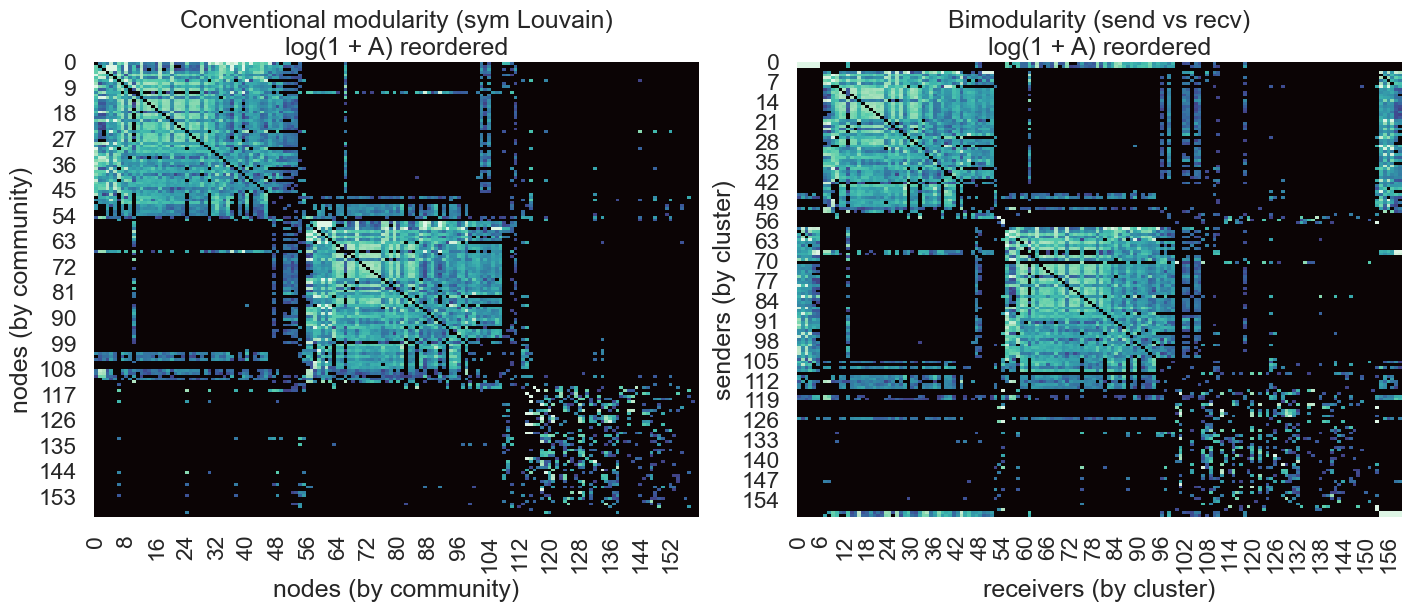

Wrote: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\adjacency_reordered_cycle_seed2_n160.png


In [33]:
# Adjacency heatmaps (reordered)
order_mod = bi._order_by_label_then_strength(A, mod_labels)
A_mod = A[np.ix_(order_mod, order_mod)]

row_order_bi = bi._order_by_label_then_strength(A, best.send_label)
col_order_bi = bi._order_by_label_then_strength(A.T, best.recv_label)
A_bi = A[np.ix_(row_order_bi, col_order_bi)]

vmax = np.percentile(A[A > 0], 99) if np.any(A > 0) else 1.0
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.heatmap(np.log1p(A_mod), ax=axes[0], cmap="mako", cbar=False, vmin=0, vmax=np.log1p(vmax))
axes[0].set_title("Conventional modularity (sym Louvain)\nlog(1 + A) reordered")
axes[0].set_xlabel("nodes (by community)")
axes[0].set_ylabel("nodes (by community)")

sns.heatmap(np.log1p(A_bi), ax=axes[1], cmap="mako", cbar=False, vmin=0, vmax=np.log1p(vmax))
axes[1].set_title("Bimodularity (send vs recv)\nlog(1 + A) reordered")
axes[1].set_xlabel("receivers (by cluster)")
axes[1].set_ylabel("senders (by cluster)")

adj_path = out_dir / f"adjacency_reordered_{run_tag}.png"
fig.savefig(adj_path, dpi=200)
plt.show()
print("Wrote:", adj_path)

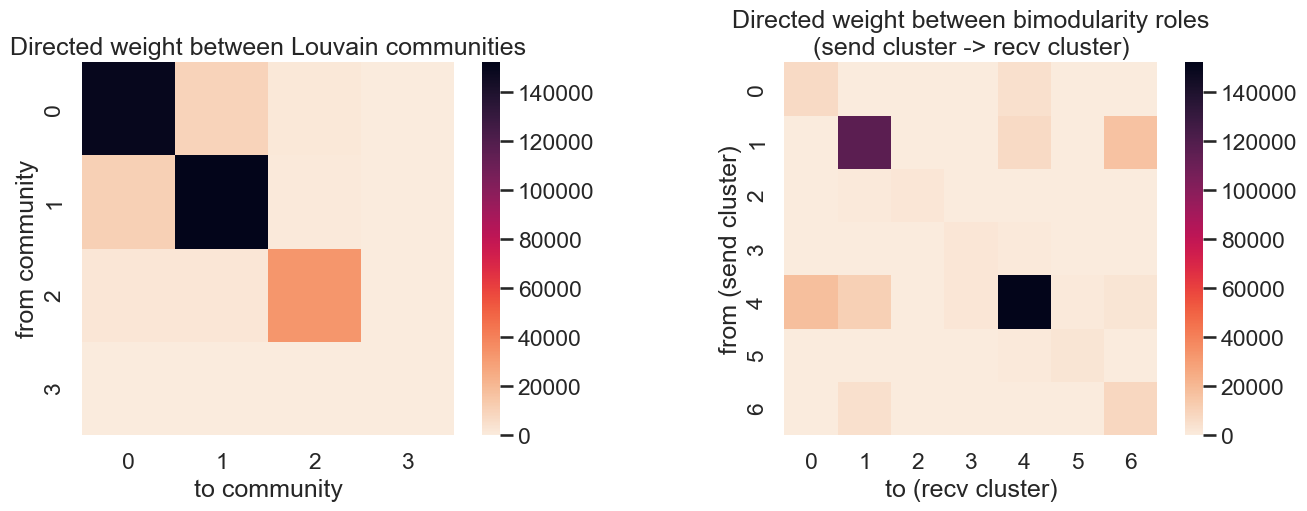

Wrote: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\block_matrices_cycle_seed2_n160.png


In [34]:
# Block matrices
block_mod = bi._coarsened_weight_matrix(A, mod_labels, mod_labels)
block_bi = bi._coarsened_weight_matrix(A, best.send_label, best.recv_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.heatmap(block_mod, ax=axes[0], cmap="rocket_r", square=True)
axes[0].set_title("Directed weight between Louvain communities")
axes[0].set_xlabel("to community")
axes[0].set_ylabel("from community")

sns.heatmap(block_bi, ax=axes[1], cmap="rocket_r", square=True)
axes[1].set_title("Directed weight between bimodularity roles\n(send cluster -> recv cluster)")
axes[1].set_xlabel("to (recv cluster)")
axes[1].set_ylabel("from (send cluster)")

block_path = out_dir / f"block_matrices_{run_tag}.png"
fig.savefig(block_path, dpi=200)
plt.show()
print("Wrote:", block_path)

In [35]:
# Node assignments CSV (same columns as script)
nodes_df_path = repo_root / "data/preprocessed/processed_nodes.csv"
node_meta = None
if nodes_df_path.exists():
    nodes_df = pd.read_csv(nodes_df_path)
    node_meta = nodes_df.set_index("id").reindex(nodes)

summary = pd.DataFrame(
    {
        "node_id": nodes,
        "send_cluster": best.send_label,
        "recv_cluster": best.recv_label,
        "mod_cluster": mod_labels,
    }
)
if node_meta is not None and "name" in node_meta.columns:
    summary["name"] = node_meta["name"].astype(str).values
if node_meta is not None and "community_label" in node_meta.columns:
    summary["community_label"] = node_meta["community_label"].astype(str).values

summary_path = out_dir / f"slice_node_assignments_{run_tag}.csv"
summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
summary.head()

Wrote: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\slice_node_assignments_cycle_seed2_n160.csv


,node_id,send_cluster,recv_cluster,mod_cluster,name,community_label
0,720575940628695043,4,4,2,SMP.LAL.6,CREa2_ventral; right
1,720575940628455942,4,4,2,SMP.LAL.4,nan
2,720575940623788040,1,6,1,AL.11,"AL local neuron,ALLN"
3,720575940623792648,4,4,0,AL.98,ALl1_dorsal; left
4,720575940632403986,4,4,0,AL.5,"il3LN6, Keystone"


In [36]:
# Bimodularity cluster contributions CSV + display
B = bi.directed_modularity_matrix_outin(A, gamma=gamma)
m_total = float(A.sum())

total_edge_w = float(best.edge_weight.sum())
edge_w_by_c = np.bincount(best.edge_cluster, weights=best.edge_weight, minlength=best.n_clusters)
edge_m_by_c = np.bincount(best.edge_cluster, minlength=best.n_clusters)
edge_w_frac = edge_w_by_c / total_edge_w if total_edge_w > 0 else np.zeros_like(edge_w_by_c)

senders_by_c = [set() for _ in range(best.n_clusters)]
receivers_by_c = [set() for _ in range(best.n_clusters)]
for (i, j), cc in zip(best.edges, best.edge_cluster, strict=True):
    c_id = int(cc)
    senders_by_c[c_id].add(int(i))
    receivers_by_c[c_id].add(int(j))

rows = []
for c in range(best.n_clusters):
    send_mask = best.send_label == c
    recv_mask = best.recv_label == c
    q_contrib = float(B[np.ix_(send_mask, recv_mask)].sum() / m_total) if m_total > 0 else 0.0
    rows.append(
        {
            "cluster": c,
            "n_senders": int(send_mask.sum()),
            "n_receivers": int(recv_mask.sum()),
            "q_contrib": q_contrib,
            "edge_weight": float(edge_w_by_c[c]),
            "edge_weight_frac": float(edge_w_frac[c]),
            "n_edges": int(edge_m_by_c[c]),
            "unique_senders": int(len(senders_by_c[c])),
            "unique_receivers": int(len(receivers_by_c[c])),
        }
    )

per_cluster_df = pd.DataFrame(rows).sort_values("q_contrib", ascending=False)
per_cluster_path = out_dir / f"bimodularity_cluster_contributions_{run_tag}.csv"
per_cluster_df.to_csv(per_cluster_path, index=False)
print("Wrote:", per_cluster_path)
per_cluster_df

Wrote: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\bimodularity_cluster_contributions_cycle_seed2_n160.csv


,cluster,n_senders,n_receivers,q_contrib,edge_weight,edge_weight_frac,n_edges,unique_senders,unique_receivers
4,4,98,98,0.183120,162952.0,0.450409,3520,115,127
1,1,51,46,0.178806,130062.0,0.359499,2627,67,65
6,6,2,6,0.019170,29847.0,0.082499,356,64,63
0,0,3,7,0.017376,27561.0,0.076180,344,63,62
5,5,2,1,0.006716,4297.0,0.011877,27,27,1
3,3,3,1,0.005257,4884.0,0.013500,42,29,14
2,2,1,1,0.005056,2184.0,0.006037,8,8,1


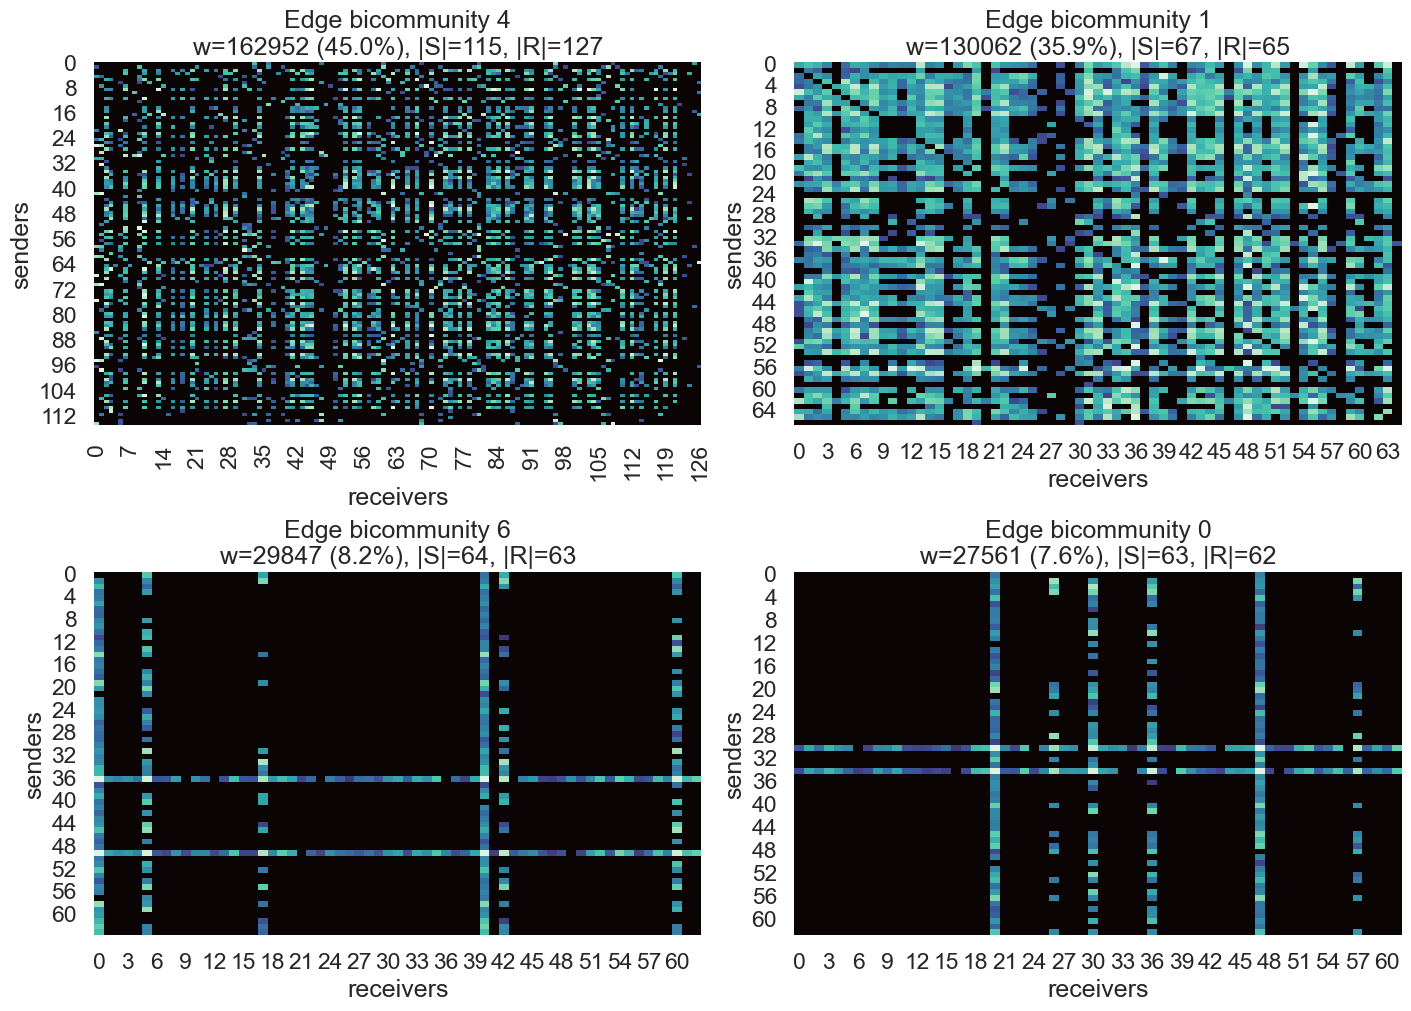

Wrote: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\bicommunity_submatrices_cycle_seed2_n160.png


In [37]:
# Top edge bicommunities as sender->receiver submatrices (same as script)
n = A.shape[0]
A_by_c = [np.zeros((n, n), dtype=float) for _ in range(best.n_clusters)]
for (i, j), cc, w in zip(best.edges, best.edge_cluster, best.edge_weight, strict=True):
    A_by_c[int(cc)][int(i), int(j)] += float(w)

top_c = (
    per_cluster_df.sort_values("edge_weight_frac", ascending=False)["cluster"].head(4).astype(int).tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()
for ax, c_id in zip(axes, top_c, strict=False):
    senders = sorted(senders_by_c[int(c_id)])
    receivers = sorted(receivers_by_c[int(c_id)])
    if not senders or not receivers:
        ax.axis("off")
        continue
    sub = A_by_c[int(c_id)][np.ix_(senders, receivers)]
    vmax_sub = np.percentile(sub[sub > 0], 99) if np.any(sub > 0) else 1.0
    sns.heatmap(np.log1p(sub), ax=ax, cmap="mako", cbar=False, vmin=0, vmax=np.log1p(vmax_sub))
    ax.set_title(
        f"Edge bicommunity {c_id}\n"
        f"w={edge_w_by_c[int(c_id)]:.0f} ({edge_w_frac[int(c_id)]:.1%}), |S|={len(senders)}, |R|={len(receivers)}"
    )
    ax.set_xlabel("receivers")
    ax.set_ylabel("senders")
for ax in axes[len(top_c):]:
    ax.axis("off")

bico_path = out_dir / f"bicommunity_submatrices_{run_tag}.png"
fig.savefig(bico_path, dpi=200)
plt.show()
print("Wrote:", bico_path)

## Notes

- For more distinct edge bicommunities, try different `seed` values and rerun.
- `output/bimodularity/bimodularity_cluster_contributions_<run_tag>.csv` is the quickest sanity check: look for several clusters with substantial `edge_weight_frac`.